## This is a sample Machine Learning project that exemplifies how to proceed Linear Regression Analysis, using Python, Pandas, NumPy, SciPy, Statsmodels, Statstests, Pingouin, Scikit-learn, Matplotlib, Seaborn and Plotly, along with Anaconda managed environments

In [1]:
!pip install --upgrade statstests # gotta install statstests through pip - not available at conda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("dark_background")
import matplotlib.cm as cm
from sklearn.preprocessing import LabelEncoder
from scipy.stats import pearsonr
from scipy.stats import boxcox
from scipy.stats import norm
from scipy import stats
from scipy.optimize import curve_fit
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from statstests.process import stepwise
from statstests.tests import shapiro_francia
from statstests.process import stepwise
import networkx as nx
import pingouin as pg
import seaborn as sns
import plotly.graph_objects as go
import os
import plotly.io as pio
if os.getenv("GITHUB_ACTIONS") == "true":
    pio.renderers.default = "png"
else:
    pio.renderers.default='colab'
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

- the formulas shown at this notebook have been taken from the following reference:

    FÁVERO, L. P.; BELFIORE, P. Manual de Análise de Dados: Estatística e Machine Learning com Excel®, SPSS®, Stata®, R® e Python®. 2ª edição, 1288 p. Brasil: ccGEN LTC, 2024.
    
    Available in Brazil at:
    
    https://www.amazon.com.br/Manual-An-C3-A1lise-Dados-Estat-C3-ADstica-Learning-dp-8595159920/dp/8595159920

## Use Case Scenario and Data - CPI = f(age,hours). Multiple Linear Regression.

This is another use-case for Generalized Linear Models (GLMs), in this case, of type Multiple Linear Regression (MLR). Here, we have a dataset that basically has the Corruption Perception Index (CPI) as a function of the average age and of the average working hours a week at 50 countries. The higher the CPI index the lesser the corruption in the country, while the lower the CPI, the greater the corruption. We have thus 2 explicative variables (X1 and X2), that, together, explain the CPI index - the dependent variable - for each of the 50 countries. We have the actual Y CPI (given at our sample dataset), as well as the estimated, predicted or expected Ŷ (Y hat) CPI values - which compose the trend spatial surface that predicts other observations at the general population. We show how to calculate the OLS (Ordinary Least Squares) linear model - finding its coefficients (linear and multiple angular ones), as well as the R2 (coefficient of determination) and adjusted R2. We also discuss a little bit about the significance of each beta (for each X) and of the alfa, showing the Fisher-Snedecor F test and the t Student tests, and, additionally, how to suspect from multicollinearity between highly-correlated explicative variables. In short, this is a simple example about MLR. For SLR, look for the respective example at this same project directory. For advanced MLR analysis, including dummyzation of qualitative variables, multicollinearity and heteroscedasticity diagnostics, stepwise method, adherence of residuals to normality (shapiro-francia) and normalization techniques (Box-Cox), check out other examples at this same project directory, as well.

In [2]:
# reading and displaying our dataset
# average age in years and average working hours in hours/week 
cpi_df = pd.read_csv('cpi.csv', delimiter=',', encoding="utf-8")
cpi_df

,country,cpi,age,hours
0,Argentina,3.9,72,35.0
1,Australia,8.7,64,32.0
2,Austria,7.9,72,32.0
3,Belgium,7.1,67,30.1
4,Brazil,4.0,59,35.0
5,Canada,8.9,61,33.4
6,Chile,6.2,70,34.0
7,China,2.5,49,34.0
8,Colombia,4.0,79,33.0
9,Cyprus,6.3,58,32.0


In [3]:
cpi_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   country  50 non-null     str    
 1   cpi      50 non-null     float64
 2   age      50 non-null     int64  
 3   hours    50 non-null     float64
dtypes: float64(2), int64(1), str(1)
memory usage: 1.7 KB


In [4]:
cpi_df.describe()

,cpi,age,hours
count,50.000000,50.000000,50.000000
mean,4.894000,60.480000,32.660000
std,2.678974,10.022913,2.431091
min,0.800000,34.000000,26.800000
25%,2.575000,58.000000,31.400000
50%,3.950000,62.000000,32.600000
75%,7.475000,66.750000,34.400000
max,9.300000,79.000000,38.100000


Multiple Linear Regression formula. Yi observed values function contains the error (deviation) ui variable, while the Ŷi expected (fitted) values function does not contain the error variable - the rest of the function expression is the same. The difference between Multiple (MLR) and Simple (SLR) Linear Regression is basically the additional angular beta coefficients, for each k explicative X variable - in this case, two beta coefficients - each one with its own significance, composing, together, the total significance of the model as a whole. The alfa and error (residual) parameters, keep being only one, each. The line is the expected (fitted) values, while the Y observed values are the dispersed, scattered, cloud of actual values that deviate from that theoretical line. The closer the dispersed actual values are from the theoretical fitted-value line, the better the predictivity of that regression model (therefore, the higher the R2). When we have more than one explicative (predictor) variable, explaining the dependent variable, we may consider the adjusted R2, which penalizes the beta of variables less significant and that do not add much to the model in terms of predictiveness, telling us how well a multiple regression model explains the data while correcting for the number of predictors. The adj R2 is specially useful for comparing prediction capacity between different OLS models, with different number of parameters (beta / predictive variables) or trained on significatively different sample sizes.

![./multiple_linear_regression.png](multiple_linear_regression.png)

![./r2-adj.png](r2-adj.png)

In [5]:
# plotting a simple 3D-scatter graph with our data

trace = go.Scatter3d(
    x=cpi_df['hours'], 
    y=cpi_df['age'], 
    z=cpi_df['cpi'], 
    mode='markers',
    marker={
        'size': 5,
        'color': 'darkorchid',
        'opacity': 0.7,
    },
)

layout = go.Layout(
    margin={'l': 0, 'r': 0, 'b': 50, 't': 0},
    width=600,
    height=400,
    plot_bgcolor='white',
    scene=dict(
        xaxis=dict(
            gridcolor='rgb(200, 200, 200)',
            backgroundcolor='whitesmoke'
        ),
        yaxis=dict(
            gridcolor='rgb(200, 200, 200)',
            backgroundcolor='whitesmoke'
        ),
        zaxis=dict(
            gridcolor='rgb(200, 200, 200)',
            backgroundcolor='whitesmoke'
        )
    )
)

data = [trace]

plot_figure = go.Figure(data=data, layout=layout)
plot_figure.update_layout(scene=dict(
    xaxis_title='hours',
    yaxis_title='age',
    zaxis_title='cpi'
))

plot_figure.show()

In [6]:
# Pearson correlation matrix and heat map graph of all quantitative variables (dependent and explicatives)
# Observe the moderately high correlation between CPI and age (0.44), as well as between CPI and hours (-0.43) - suggests 
# moderate high betas for both X variables and moderate high R2
# Observe also some lower, yet existent, correlation between age and hours, themselves (-0.19) - check for multicollinearity 
# between X variables
correlation_matrix = cpi_df.iloc[:,1:4].corr()
correlation_matrix

,cpi,age,hours
cpi,1.000000,0.442838,-0.435724
age,0.442838,1.000000,-0.191748
hours,-0.435724,-0.191748,1.000000


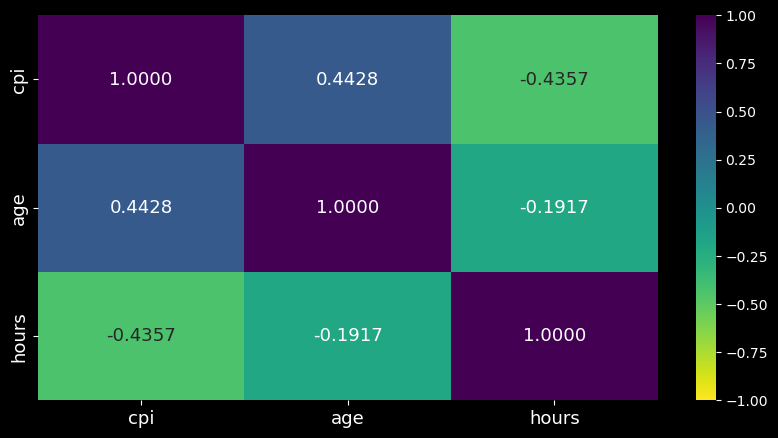

In [7]:
plt.figure(figsize=(10, 5))
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt=".4f",
                      cmap=plt.cm.viridis_r,
                      annot_kws={'size': 13}, vmin=-1, vmax=1)
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=13)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=13)
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
plt.show()

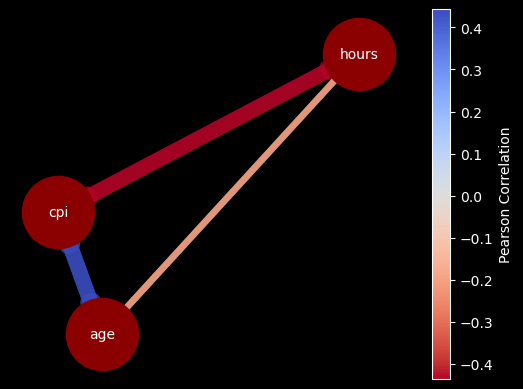

In [8]:
# creating a directed graph showing the correlations (and their magnitudes) between all variables
# Useful when evaluating multicollinearity
# We may verify the same correlations mentioned above, including between the two X variables (age and hours)
G = nx.DiGraph()

for variable in correlation_matrix.columns:
    G.add_node(variable)

for i, variable1 in enumerate(correlation_matrix.columns):
    for j, variable2 in enumerate(correlation_matrix.columns):
        if i != j:
            correlation = correlation_matrix.iloc[i, j]
            if abs(correlation) > 0:
                G.add_edge(variable1, variable2, weight=correlation)

correlations = [d["weight"] for _, _, d in G.edges(data=True)]

node_size = 2700

node_color = 'darkred'

cmap = plt.colormaps.get_cmap('coolwarm_r')

edge_widths = [abs(d["weight"]) * 25 for _, _, d in G.edges(data=True)]

pos = nx.spring_layout(G, k=0.75)

nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_color)
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=correlations,
                       edge_cmap=cmap, alpha=0.7)

labels = {node: node for node in G.nodes}
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color='white')

ax = plt.gca()
ax.margins(0.1)
plt.axis("off")

smp = cm.ScalarMappable(cmap=cmap)
smp.set_array([min(correlations), max(correlations)])
cbar = plt.colorbar(smp, ax=ax, label='Pearson Correlation')

plt.show()

In [9]:
# Pearson correlation matrix with p-values (should show p-values with stars, instead of correlations, at upper triangle)
correlation_matrix2 = pg.rcorr(cpi_df, method='pearson',
                               upper='pval', decimals=6,
                               pval_stars={0.01: '***',
                                           0.05: '**',
                                           0.10: '*'})
correlation_matrix2

,cpi,age,hours
cpi,1.0,0.442838,-0.435724
age,0.442838,1.0,-0.191748
hours,-0.435724,-0.191748,1.0


<Figure size 2000x1000 with 0 Axes>

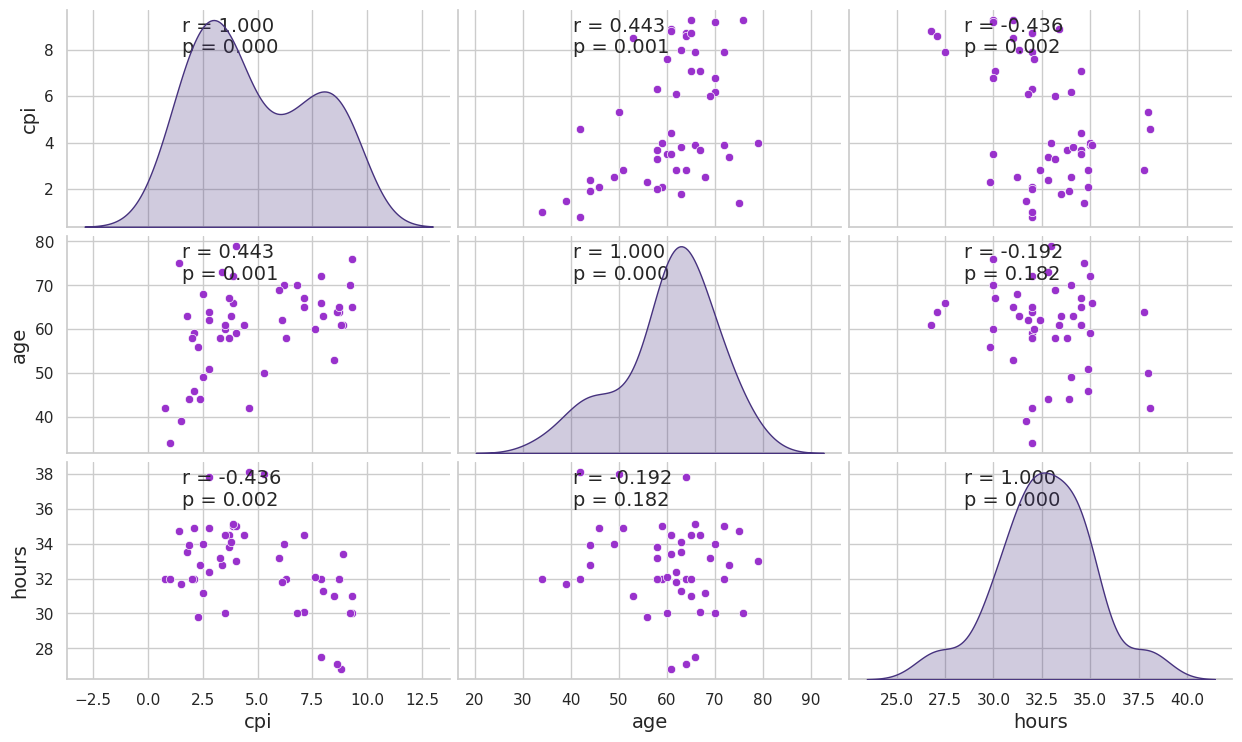

In [10]:
# a graph with scatters, pearson correlation (r) and p-values for each variable pair
def corrfunc(x, y, **kws):
    (r, p) = pearsonr(x, y)
    ax = plt.gca()
    ax.annotate("r = {:.3f}".format(r),
                xy=(.30, .9), xycoords=ax.transAxes, fontsize=14)
    ax.annotate("p = {:.3f}".format(p),
                xy=(.30, .8), xycoords=ax.transAxes, fontsize=14)

sns.set(style="whitegrid", palette="viridis")

plt.figure(figsize=(20,10))
graph = sns.pairplot(cpi_df, diag_kind="kde",
                     plot_kws={"color": "darkorchid"},
                     height=2.5, aspect=1.7)
graph.map(corrfunc)
for ax in graph.axes.flat:
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)
plt.show()

In [11]:
# Estimating and displaying the OLS model
# Observe that the probability value (p-value) of the F test (for the significance of the model as a whole) is much less than
# 0.05, indicating that, at least one of the betas (and respective variable) at our model is significant as well.
# Observe also that the p-values for the t Student tests for all parameters - alfa and the two betas - are also lower than 0.05,
# proving the significance not only of our alfa, but of the beta for each individual explicative X variable, i.e., age and hours,
# meaning that both contribute to the general model significance (F test).
# The alfa, despite being significant or not, MUST always be kept at our regression model expression (we MUST NEVER ommit it).
# The betas, and respective variables, should be kept as long as they're significant when explaining the dependent variable. If 
# one or another beta is not, the respective variable, in principle, should be excluded from the model, as it's coefficient is
# statistically zero. There are ways we may adjust that, in order to keep the insignificant beta if we can turn it significant
# after normalizing the model, for example by using Box-Cox method.
# We analyse multicollinearity and heteroscedasticity, as well as the adherence of residuals to normality (shapiro-francia) and 
# normalization techniques (Box-Cox) at another example at this same project directory.
# For this particular model, we don't have to do anything else, everything is significant, as the model itself (although R2 is 
# not that great). We may use the model for making any predictions on CPI values based on AGE and HOURS inputs, taken from the 
# population, in general, within the same interpolation of the sample data used to train such a model.
cpi_model = sm.OLS.from_formula("cpi ~ age + hours", cpi_df).fit()
cpi_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cpi   R-squared:                       0.324
Model:                            OLS   Adj. R-squared:                  0.295
Method:                 Least Squares   F-statistic:                     11.26
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           0.000101
Time:                        14:14:15   Log-Likelihood:                -109.93
No. Observations:                  50   AIC:                             225.9
Df Residuals:                      47   BIC:                             231.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.9719      5.165      2.318      0.025       1.581      22.363
age            0.0997      0.033      3.052      0.004       0.034       0.165
hours         -0.4013      0.135     -2.980      0.005      -0.672      -0.130
==============================================================================
Omnibus:                        3.389   Durbin-Watson:                   1.822
Prob(Omnibus):                  0.184   Jarque-Bera (JB):                1.762
Skew:                           0.131   Prob(JB):                        0.414
Kurtosis:                       2.119   Cond. No.                     1.13e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.13e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [12]:
# mounting the model (trend spatial surface) equation
params = cpi_model.params
print(f'alfa (intercept) = {params["Intercept"]}\nbeta1 (age slope) = {params["age"]}\nbeta2 (hours slope) = {params["hours"]}')

terms = [f"{coef:.4f}*{name}" for name, coef in params.items() if name != "Intercept"]
equation = f"CPI = {params['Intercept']:.4f} + " + " + ".join(terms)
print(equation)

alfa (intercept) = 11.971915314376107
beta1 (age slope) = 0.09969811386971936
beta2 (hours slope) = -0.4013367189594836
CPI = 11.9719 + 0.0997*age + -0.4013*hours


In [13]:
# manually calculating adjusted R2 (already available at the model summary above)
r2_adj = 1-((len(cpi_df.index)-1)/(len(cpi_df.index)-cpi_model.params.count()))*(1-cpi_model.rsquared)
print(r2_adj)

0.295099700531963


In [14]:
# or, directly:
print(cpi_model.rsquared_adj)

0.295099700531963


In [15]:
# adding calculated Ŷi (fitted values) to the dataset
cpi_df['cpi-fitted (Ŷi)'] = cpi_model.fittedvalues
cpi_df["residual (ui)"] = cpi_model.resid
cpi_df

,country,cpi,age,hours,cpi-fitted (Ŷi),residual (ui)
0,Argentina,3.9,72,35.0,5.103394,-1.203394
1,Australia,8.7,64,32.0,5.509820,3.190180
2,Austria,7.9,72,32.0,6.307405,1.592595
3,Belgium,7.1,67,30.1,6.571454,0.528546
4,Brazil,4.0,59,35.0,3.807319,0.192681
5,Canada,8.9,61,33.4,4.648854,4.251146
6,Chile,6.2,70,34.0,5.305335,0.894665
7,China,2.5,49,34.0,3.211674,-0.711674
8,Colombia,4.0,79,33.0,6.603955,-2.603955
9,Cyprus,6.3,58,32.0,4.911631,1.388369


In [16]:
# plotting a 3D-graph with scattered observed values along with a spatial surface with fitted values
# As we're now working on a 3D space, instead of a fitted-values' line, we have a fitted-values' spatial surface (3D)
# For SLR, we only have two variables, 1 Y and 1 X, so it's always a 2D-space, and therefore a trend line with fitted values
# For MLR, we have at least one more variable, so, at least a 3D-space for 1 Y and 2 X variables, and therefore a trend spatial 
# surface with fitted values, instead

scatter = go.Scatter3d(
    x=cpi_df['hours'],
    y=cpi_df['age'],
    z=cpi_df['cpi'],
    mode='markers',
    marker=dict(
        size=5,
        color='darkorchid',
        opacity=0.7
    ),
    name='Observed'
)

X = np.column_stack([
    np.ones(len(cpi_df)),
    cpi_df['hours'],
    cpi_df['age']
])

y = cpi_df['cpi'].values

b0, b1, b2 = np.linalg.lstsq(X, y, rcond=None)[0]

hours_grid = np.linspace(cpi_df['hours'].min(),
                          cpi_df['hours'].max(), 50)

age_grid = np.linspace(cpi_df['age'].min(),
                          cpi_df['age'].max(), 50)

H, I = np.meshgrid(hours_grid, age_grid)

Z = b0 + b1 * H + b2 * I

surface = go.Surface(
    x=hours_grid,
    y=age_grid,
    z=Z,
    colorscale='Oranges',
    opacity=0.6,
    showscale=False,
    name='Adjusted Surface'
)

fig = go.Figure(data=[scatter, surface])

fig.update_layout(
    width=600,
    height=400,
    margin=dict(l=0, r=0, b=50, t=0),
    plot_bgcolor='white',
    scene=dict(
        xaxis=dict(
            title='hours',
            gridcolor='rgb(200,200,200)',
            backgroundcolor='whitesmoke'
        ),
        yaxis=dict(
            title='age',
            gridcolor='rgb(200,200,200)',
            backgroundcolor='whitesmoke'
        ),
        zaxis=dict(
            title='cpi',
            gridcolor='rgb(200,200,200)',
            backgroundcolor='whitesmoke'
        )
    )
)

In [17]:
# Let's make some predictions based on the regression model above (have in mind that the prediction is only valid for values inside the
# variables' interpolation range):
# CPI predicted for a age=40 and hours=36 ?
print(f'CPI for avg age = 40 years and avg hours of work per week = 36 hours => {round(cpi_model.params["Intercept"]+cpi_model.params["age"]*40+cpi_model.params["hours"]*36,1)}.')
# CPI predicted for a age=70 and hours=27 ?
print(f'CPI for avg age = 70 years and avg hours of work per week = 27 hours => {round(cpi_model.params["Intercept"]+cpi_model.params["age"]*70+cpi_model.params["hours"]*27,1)}.')

CPI for avg age = 40 years and avg hours of work per week = 36 hours => 1.5.
CPI for avg age = 70 years and avg hours of work per week = 27 hours => 8.1.


In [18]:
# or:
print(f"CPI for avg age = 40 years and avg hours of work per week = 36 hours => {cpi_model.predict(pd.DataFrame({'age':[40],'hours':[36]}))[0]}.")
print(f"CPI for avg age = 70 years and avg hours of work per week = 27 hours => {cpi_model.predict(pd.DataFrame({'age':[70],'hours':[27]}))[0]}.")

CPI for avg age = 40 years and avg hours of work per week = 36 hours => 1.5117179866234718.
CPI for avg age = 70 years and avg hours of work per week = 27 hours => 8.114691873350406.
